# Análisis de actividad del CMS Joomla vía PostgreSQL

Este cuaderno se conecta directamente a la base de datos `PostgreSQL` compartida con Joomla
y con Grafana, y genera un análisis/gráfica de la actividad de la base de datos como proxy
del tráfico web recibido por el CMS a través del proxy inverso de Nginx.

No requiere ninguna configuración manual: las credenciales se toman de las variables de
entorno inyectadas por `docker-compose.yml` (definidas en `.env`).

In [1]:
import os
import pandas as pd
from sqlalchemy import create_engine, text
from sqlalchemy.exc import SQLAlchemyError
from IPython.display import HTML, display

# 1. Variables de Entorno y Credenciales
PG_HOST = os.environ.get('POSTGRES_HOST', 'database')
PG_PORT = os.environ.get('POSTGRES_PORT', '5432')
PG_DB   = os.environ.get('POSTGRES_DB', 'joomladb')
PG_USER = os.environ.get('POSTGRES_USER', 'joomla_user')
PG_PASS = os.environ.get('POSTGRES_PASSWORD', 'joomla_pass_123')

# 2. Creación del Engine
engine = create_engine(f'postgresql+psycopg2://{PG_USER}:{PG_PASS}@{PG_HOST}:{PG_PORT}/{PG_DB}')

# 3. Función de consulta con manejo de errores y soporte para parámetros
def run_query(sql, params=None):
    """Ejecuta una consulta SQL y retorna un DataFrame.
    Incluye un bloque try-except para evitar que errores SQL detengan el notebook."""
    try:
        with engine.connect() as conn:
            result = conn.execute(text(sql), params or {})
            return pd.DataFrame(result.fetchall(), columns=list(result.keys()))
    except SQLAlchemyError as e:
        print(f"❌ Error en la consulta SQL: {e}")
        # Retorna un DataFrame vacío para que las celdas de gráficos no colapsen
        return pd.DataFrame() 

# 4. Prueba de conexión con diseño visual unificado al Dashboard
try:
    with engine.connect() as conn:
        version = conn.execute(text('SELECT version();')).scalar()
        
    html_status = f"""
    <div style="background-color: #0b111a; padding: 16px; border-radius: 8px; border: 1px solid #1c2433; border-left: 4px solid #10b981; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', sans-serif; max-width: 800px;">
        <h4 style="color: #e2e8f0; margin: 0 0 8px 0; font-size: 14px; text-transform: uppercase; letter-spacing: 0.5px;">
            Conexión Establecida a PostgreSQL
        </h4>
        <p style="color: #8b9bb4; margin: 0 0 12px 0; font-size: 13px;">
            <b>Host:</b> {PG_HOST}:{PG_PORT} &nbsp;|&nbsp; <b>Base de Datos:</b> {PG_DB} &nbsp;|&nbsp; <b>Usuario:</b> {PG_USER}
        </p>
        <div style="padding: 10px; background-color: #0f1722; border-radius: 4px; color: #64829c; font-family: Consolas, monospace; font-size: 12px; border: 1px solid #162032;">
            {version}
        </div>
    </div>
    """
    display(HTML(html_status))
    
except SQLAlchemyError as e:
    html_error = f"""
    <div style="background-color: #0b111a; padding: 16px; border-radius: 8px; border: 1px solid #1c2433; border-left: 4px solid #ef4444; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', sans-serif; max-width: 800px;">
        <h4 style="color: #e2e8f0; margin: 0 0 8px 0; font-size: 14px; text-transform: uppercase; letter-spacing: 0.5px;">
            Error de Conexión a Base de Datos
        </h4>
        <p style="color: #ef4444; margin: 0; font-size: 12.5px; font-family: Consolas, monospace;">{e}</p>
    </div>
    """
    display(HTML(html_error))

## 1. Tablas creadas por Joomla en la base de datos
Lista todas las tablas del esquema público (independiente del prefijo aleatorio que Joomla
asigna en la instalación desatendida).

In [2]:
from IPython.display import HTML, display

df_tablas = run_query("""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'public'
    ORDER BY table_name;
""")

if not df_tablas.empty:
    # Generar tarjetas HTML con retraso escalonado
    cards_html = ""
    for i, tabla in enumerate(df_tablas['table_name']):
        delay = i * 0.02 # Acelerado ligeramente para que la animación sea más fluida
        # Se añade un ícono de tabla usando un caracter unicode para mayor estética
        cards_html += f"<div class='tb-card' style='animation-delay: {delay}s;'>🗄️ {tabla}</div>"

    estilos = """
    <style>
        .db-wrapper {
            background-color: #0b1324;
            padding: 25px;
            border-radius: 8px;
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            box-shadow: inset 0 0 15px rgba(0,0,0,0.4);
        }
        .db-header {
            color: #ffffff;
            font-size: 16px;
            font-weight: bold;
            margin-bottom: 20px;
            padding-bottom: 12px;
            border-bottom: 1px solid #2c3645;
        }
        .db-header span {
            color: #8b9bb4;
            font-weight: normal;
            font-size: 13px;
            margin-left: 8px;
        }
        /* CSS Grid para alinear todo en columnas perfectas */
        .db-grid {
            display: grid;
            grid-template-columns: repeat(auto-fill, minmax(240px, 1fr));
            gap: 12px;
        }
        .tb-card {
            background-color: #1e2a3b; /* Fondo más claro que el anterior */
            color: #e2e8f0; /* Texto casi blanco para alto contraste */
            padding: 10px 14px;
            border: 1px solid #2c3e50;
            border-left: 3px solid #00b8ff; /* Acento visual azul */
            border-radius: 4px;
            font-size: 12.5px;
            font-family: 'Consolas', 'Courier New', monospace; /* Letra tipo código */
            white-space: nowrap;
            overflow: hidden;
            text-overflow: ellipsis; /* Puntos suspensivos si el nombre es muy largo */
            opacity: 0;
            transform: translateY(10px);
            animation: slideFadeUp 0.3s ease forwards;
            transition: all 0.2s ease;
            cursor: pointer;
        }
        .tb-card:hover {
            background-color: #27374d; /* Se ilumina aún más al pasar el mouse */
            border-left: 3px solid #00ff88; /* El acento cambia a verde neón */
            color: #ffffff;
            transform: translateY(-2px);
            box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2);
        }
        @keyframes slideFadeUp {
            to {
                opacity: 1;
                transform: translateY(0);
            }
        }
    </style>
    """
    
    html_final = f"""
    {estilos}
    <div class="db-wrapper">
        <div class="db-header">
            Esquema Público <span>({len(df_tablas)} tablas detectadas)</span>
        </div>
        <div class="db-grid">
            {cards_html}
        </div>
    </div>
    """
    display(HTML(html_final))
else:
    print("No se encontraron tablas en el esquema 'public'.")

## 2. Actividad de escritura por tabla (proxy de tráfico del CMS)
Cada visita al portal Joomla genera lecturas/escrituras de sesión y contenido en PostgreSQL.
Esta consulta usa las vistas de estadísticas internas de PostgreSQL (`pg_stat_user_tables`),
que no dependen del prefijo de tablas de Joomla.

In [3]:
from IPython.display import HTML, display
import pandas as pd

df_actividad = run_query("""
    SELECT relname AS tabla,
           n_tup_ins AS inserts,
           n_tup_upd AS updates,
           n_tup_del AS deletes
    FROM pg_stat_user_tables
    ORDER BY (n_tup_ins + n_tup_upd) DESC
    LIMIT 10;
""")

if not df_actividad.empty:
    rows_html = ""
    for _, row in df_actividad.iterrows():
        tabla = row['tabla']
        ins = row['inserts']
        upd = row['updates']
        del_ = row['deletes']

        def format_metric(val, color_class):
            if val > 0:
                return f"<span class='{color_class}'>{val:,}</span>"
            return "<span class='zero-val'>0</span>"

        ins_html = format_metric(ins, 'val-ins')
        upd_html = format_metric(upd, 'val-upd')
        del_html = format_metric(del_, 'val-del')

        rows_html += f"""
        <tr>
            <td class="col-table" title="{tabla}">{tabla}</td>
            <td class="right-align">{ins_html}</td>
            <td class="right-align">{upd_html}</td>
            <td class="right-align">{del_html}</td>
        </tr>
        """

    estilos = """
    <style>
        .activity-container {
            background-color: #0b111a !important; 
            padding: 20px !important;
            border-radius: 8px !important;
            border: 1px solid #1c2433 !important;
            font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif !important;
            max-width: 800px !important;
        }
        .activity-header {
            font-size: 14px !important;
            font-weight: 600 !important;
            margin-bottom: 12px !important;
            color: #8b9bb4 !important;
            text-transform: uppercase !important;
            letter-spacing: 0.8px !important;
            display: flex !important;
            justify-content: space-between !important;
            align-items: center !important;
        }
        .activity-header .subtitle {
            font-size: 11px !important;
            color: #475569 !important;
            font-weight: normal !important;
            text-transform: none !important;
        }
        
        /* Omoĩ porã umi columnas ani haguã oñembojo'a */
        .activity-container table {
            width: 100% !important;
            table-layout: fixed !important; 
            border-collapse: collapse !important;
            margin: 0 !important;
            border: none !important;
        }
        
        /* Ome'ẽ hetave tenda pe térape guarã (45%) */
        .activity-container th:first-child,
        .activity-container td:first-child {
            width: 45% !important; 
        }
        .activity-container th:not(:first-child),
        .activity-container td:not(:first-child) {
            width: 18.33% !important;
        }

        .activity-container th {
            text-align: left !important;
            padding: 12px 16px !important;
            background-color: #0b111a !important;
            color: #64748b !important;
            font-size: 11.5px !important;
            font-weight: bold !important;
            border-bottom: 1px solid #1e293b !important;
        }
        .activity-container th.right-align,
        .activity-container td.right-align {
            text-align: right !important;
        }

        .activity-container tbody tr:nth-child(n) td {
            text-align: left !important;
            padding: 12px 16px !important;
            background-color: #0f1722 !important;
            border: none !important;
            border-bottom: 1px solid #162032 !important;
            transition: all 0.15s ease-in-out !important;
        }

        .activity-container tbody tr:hover td {
            background-color: #182336 !important;
        }
        .activity-container tbody tr:hover td:first-child {
            box-shadow: inset 4px 0 0 0 #8b5cf6 !important; 
        }

        .col-table {
            font-family: "SFMono-Regular", Consolas, "Liberation Mono", Courier, monospace !important;
            font-size: 13px !important;
            color: #e2e8f0 !important; 
            font-weight: 500 !important;
            white-space: nowrap !important;
            overflow: hidden !important;
            text-overflow: ellipsis !important; /* Oñemoĩ ... ipukuetereirõ */
        }
        
        .val-ins, .val-upd, .val-del, .zero-val {
            font-family: "SFMono-Regular", Consolas, "Liberation Mono", Courier, monospace !important;
            font-size: 13.5px !important;
            font-weight: 600 !important;
            letter-spacing: 0.5px !important;
        }
        .val-ins { color: #10b981 !important; } 
        .val-upd { color: #f59e0b !important; } 
        .val-del { color: #ef4444 !important; } 
        
        .zero-val { 
            color: #334155 !important; 
            font-weight: 400 !important; 
        }
    </style>
    """
    
    html_final = f"""
    {estilos}
    <div class="activity-container">
        <div class="activity-header">
            Top 10 Tablas de Mayor Actividad
            <span class="subtitle">Inserts + Updates</span>
        </div>
        <table>
            <thead>
                <tr>
                    <th>Nombre de la Tabla</th>
                    <th class="right-align">Inserts</th>
                    <th class="right-align">Updates</th>
                    <th class="right-align">Deletes</th>
                </tr>
            </thead>
            <tbody>
                {rows_html}
            </tbody>
        </table>
    </div>
    """
    display(HTML(html_final))
else:
    print("Ndaijái data ikatu haguã ojehechauka.")

Nombre de la Tabla,Inserts,Updates,Deletes
joom_extensions,251,252,0
joom_guidedtour_steps,117,234,0
joom_finder_terms_common,174,0,0
joom_assets,92,0,0
joom_modules_menu,39,0,0
joom_modules,36,0,0
joom_guidedtours,12,24,0
joom_mail_templates,33,0,0
joom_action_log_config,23,0,0
joom_menu,22,0,0


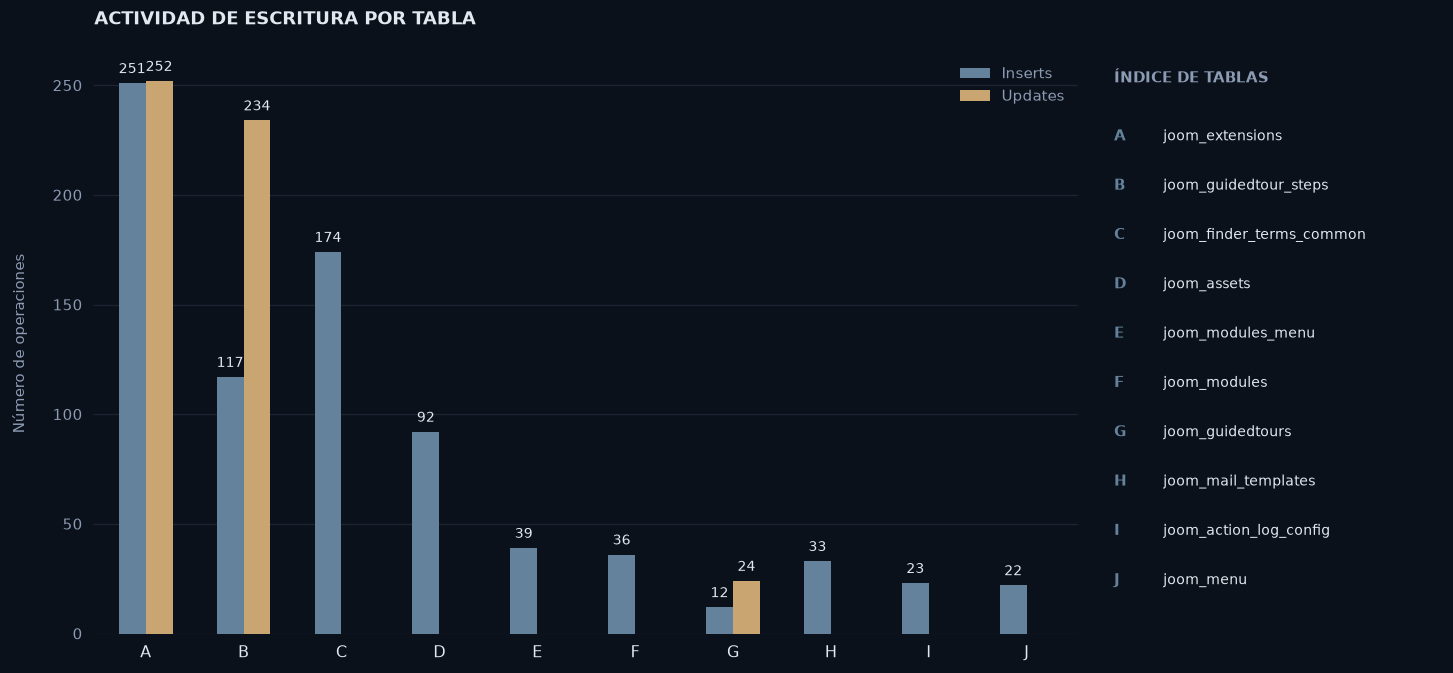

In [4]:
import matplotlib.pyplot as plt

if not df_actividad.empty:
    color_inserts = '#64829c'
    color_updates = '#c9a671'
    bg_color = '#0b111a'
    grid_color = '#1c2433'
    text_color = '#8b9bb4'
    text_highlight = '#e2e8f0'
    
    tablas_originales = df_actividad['tabla'].tolist()
    etiquetas_cortas = [chr(65 + i) for i in range(len(tablas_originales))]
    
    df_plot = df_actividad.copy()
    df_plot['id'] = etiquetas_cortas
    
    fig, (ax_bar, ax_ref) = plt.subplots(
        1, 2, 
        figsize=(12, 5.5), 
        facecolor=bg_color,
        dpi=120,
        gridspec_kw={'width_ratios': [3.6, 1.2], 'wspace': 0.05},
        constrained_layout=True
    )
    
    ax_bar.set_facecolor(bg_color)
    df_plot.set_index('id')[['inserts', 'updates']].plot(
        kind='bar', ax=ax_bar, 
        color=[color_inserts, color_updates], 
        width=0.55, edgecolor='none'  # Barras ligeramente más esbeltas
    )
    
    # Título más pequeño y elegante
    ax_bar.text(0, 1.05, 'ACTIVIDAD DE ESCRITURA POR TABLA', transform=ax_bar.transAxes, 
                color=text_highlight, fontsize=10.5, fontweight='bold')
    
    ax_bar.set_ylabel('Número de operaciones', fontsize=9, color=text_color, labelpad=15)
    ax_bar.set_xlabel('') 
    
    # Reducción de las letras del eje X para mayor fineza
    ax_bar.tick_params(axis='x', rotation=0, colors=text_highlight, labelsize=9.5, bottom=False)
    ax_bar.tick_params(axis='y', colors=text_color, labelsize=9, left=False)
    
    ax_bar.grid(axis='y', color=grid_color, alpha=1, linestyle='-')
    ax_bar.set_axisbelow(True)
    for spine in ax_bar.spines.values():
        spine.set_visible(False)
    
    # Leyenda más sutil
    ax_bar.legend(['Inserts', 'Updates'], frameon=False, 
                  loc='upper right', labelcolor=text_color, fontsize=9)
    
    # Etiquetas de barras más pequeñas
    for container in ax_bar.containers:
        labels = [f'{int(v)}' if v > 0 else '' for v in container.datavalues]
        ax_bar.bar_label(container, labels=labels, padding=4, color=text_highlight, fontsize=8.5)

    # ==========================================
    # PANEL DERECHO: ÍNDICE DE TABLAS MÁS ELEGANTE
    # ==========================================
    ax_ref.axis('off')
    ax_ref.set_facecolor(bg_color)
    
    # Título del índice proporcionado
    ax_ref.text(0, 0.95, 'ÍNDICE DE TABLAS', 
                color=text_color, fontsize=9, fontweight='bold', transform=ax_ref.transAxes)
    
    y_pos = 0.85
    espaciado = 0.85 / max(len(tablas_originales), 1)
    
    for letra, tabla in zip(etiquetas_cortas, tablas_originales):
        # Letras del índice (más pequeñas y sutiles)
        ax_ref.text(0, y_pos, letra, color=color_inserts, 
                    fontsize=9, fontweight='bold', transform=ax_ref.transAxes)
        # Nombres de las tablas (texto reducido a 8.5 y mayor margen izquierdo '0.15' para respirar)
        ax_ref.text(0.15, y_pos, tabla, color=text_highlight, 
                    fontsize=8.5, transform=ax_ref.transAxes)
        y_pos -= espaciado

    plt.savefig('actividad_tablas.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()

else:
    print('Aún no hay actividad registrada. Genera tráfico navegando el portal Joomla y vuelve a ejecutar esta celda.')

## 3. Conexiones activas / IPs recurrentes hacia PostgreSQL
Refleja qué clientes (contenedores/servicios) están consultando la base de datos en este
momento -- la misma consulta que usa el panel de Grafana.

In [5]:
from IPython.display import HTML, display
import pandas as pd

df_conexiones = run_query("""
    SELECT COALESCE(host(client_addr), 'local') AS ip_cliente,
           application_name,
           state,
           count(*) AS conexiones
    FROM pg_stat_activity
    WHERE datname = current_database()
    GROUP BY host(client_addr), application_name, state
    ORDER BY conexiones DESC;
""")

if not df_conexiones.empty:
    rows_html = ""
    for _, row in df_conexiones.iterrows():
        ip = row['ip_cliente']
        app = row['application_name'] if pd.notna(row['application_name']) and row['application_name'] != '' else '<span class="empty-app">Sin especificar</span>'
        state = str(row['state']).lower()
        conns = row['conexiones']

        if state == 'active':
            badge = f"<span class='badge badge-active'>active</span>"
        elif state == 'idle':
            badge = f"<span class='badge badge-idle'>idle</span>"
        else:
            badge = f"<span class='badge badge-other'>{state}</span>"

        rows_html += f"""
        <tr>
            <td class="col-ip">{ip}</td>
            <td class="col-app">{app}</td>
            <td class="col-state">{badge}</td>
            <td class="col-conn">{conns}</td>
        </tr>
        """

    estilos = """
    <style>
        /* Contenedor principal */
        .monitor-container {
            background-color: #0b111a !important; 
            padding: 20px !important;
            border-radius: 8px !important;
            border: 1px solid #1c2433 !important;
            font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif !important;
            max-width: 850px !important;
        }
        .monitor-header {
            font-size: 14px !important;
            font-weight: 600 !important;
            margin-bottom: 12px !important;
            color: #8b9bb4 !important;
            text-transform: uppercase !important;
            letter-spacing: 0.8px !important;
        }
        .monitor-container table {
            width: 100% !important;
            border-collapse: collapse !important;
            margin: 0 !important;
            border: none !important;
        }
        
        /* Cabeceras */
        .monitor-container th {
            text-align: left !important;
            padding: 12px 16px !important;
            background-color: #0b111a !important; /* Fuerza fondo oscuro */
            color: #64748b !important;
            font-size: 11.5px !important;
            font-weight: bold !important;
            border-bottom: 1px solid #1e293b !important;
        }
        .monitor-container th.right-align {
            text-align: right !important;
        }

        /* 
         * CORRECCIÓN DE LEGIBILIDAD: 
         * Forzamos el color de fondo y texto directamente en la celda (td) 
         * sin importar si la fila es par o impar (nth-child) 
         */
        .monitor-container tbody tr:nth-child(n) td {
            text-align: left !important;
            padding: 12px 16px !important;
            background-color: #0f1722 !important; /* Fondo oscuro estricto para cada celda */
            border: none !important;
            border-bottom: 1px solid #162032 !important;
            transition: all 0.15s ease-in-out !important; /* Transición suave */
        }

        /* 
         * EL GESTO AL PASAR EL MOUSE: 
         * La fila se ilumina y aparece una línea guía a la izquierda 
         */
        .monitor-container tbody tr:hover td {
            background-color: #182336 !important; /* Se aclara ligeramente */
        }
        .monitor-container tbody tr:hover td:first-child {
            box-shadow: inset 4px 0 0 0 #00b8ff !important; /* Línea azul indicadora */
        }

        /* Datos tipográficos */
        .col-ip {
            font-family: "SFMono-Regular", Consolas, "Liberation Mono", Courier, monospace !important;
            font-size: 13px !important;
            color: #38bdf8 !important; /* Azul cyan visible al instante */
        }
        .col-app {
            font-size: 13px !important;
            color: #cbd5e1 !important; /* Gris claro de alta visibilidad */
        }
        .empty-app {
            color: #64748b !important;
            font-style: italic !important;
        }
        .col-conn {
            text-align: right !important;
            font-family: "SFMono-Regular", Consolas, "Liberation Mono", Courier, monospace !important;
            color: #f8fafc !important; /* Blanco puro para los números */
            font-weight: 600 !important;
            font-size: 14px !important;
        }
        
        /* Badges Minimalistas */
        .badge {
            display: inline-block !important;
            padding: 3px 8px !important;
            border-radius: 4px !important; /* Más cuadrados, estilo minimalista */
            font-size: 11px !important;
            font-weight: bold !important;
            letter-spacing: 0.5px !important;
            text-transform: uppercase !important;
        }
        .badge-active {
            color: #10b981 !important;
            background-color: rgba(16, 185, 129, 0.1) !important;
            border: 1px solid rgba(16, 185, 129, 0.3) !important;
        }
        .badge-idle {
            color: #94a3b8 !important;
            background-color: rgba(148, 163, 184, 0.05) !important;
            border: 1px solid rgba(148, 163, 184, 0.2) !important;
        }
        .badge-other {
            color: #f59e0b !important;
            background-color: rgba(245, 158, 11, 0.1) !important;
            border: 1px solid rgba(245, 158, 11, 0.3) !important;
        }
    </style>
    """
    
    html_final = f"""
    {estilos}
    <div class="monitor-container">
        <div class="monitor-header">Conexiones Activas a Base de Datos</div>
        <table>
            <thead>
                <tr>
                    <th>IP Cliente</th>
                    <th>Aplicación</th>
                    <th>Estado</th>
                    <th class="right-align">Conexiones</th>
                </tr>
            </thead>
            <tbody>
                {rows_html}
            </tbody>
        </table>
    </div>
    """
    display(HTML(html_final))
else:
    print("No hay conexiones activas que mostrar.")

IP Cliente,Aplicación,Estado,Conexiones
172.20.0.3,Sin especificar,active,1


## 6. Diagrama 3D de la arquitectura del sistema
Visualización 3D interactiva de los 5 contenedores, sus redes (`frontend_net` en azul, `backend_net` en rojo) y el flujo de tráfico entre ellos.

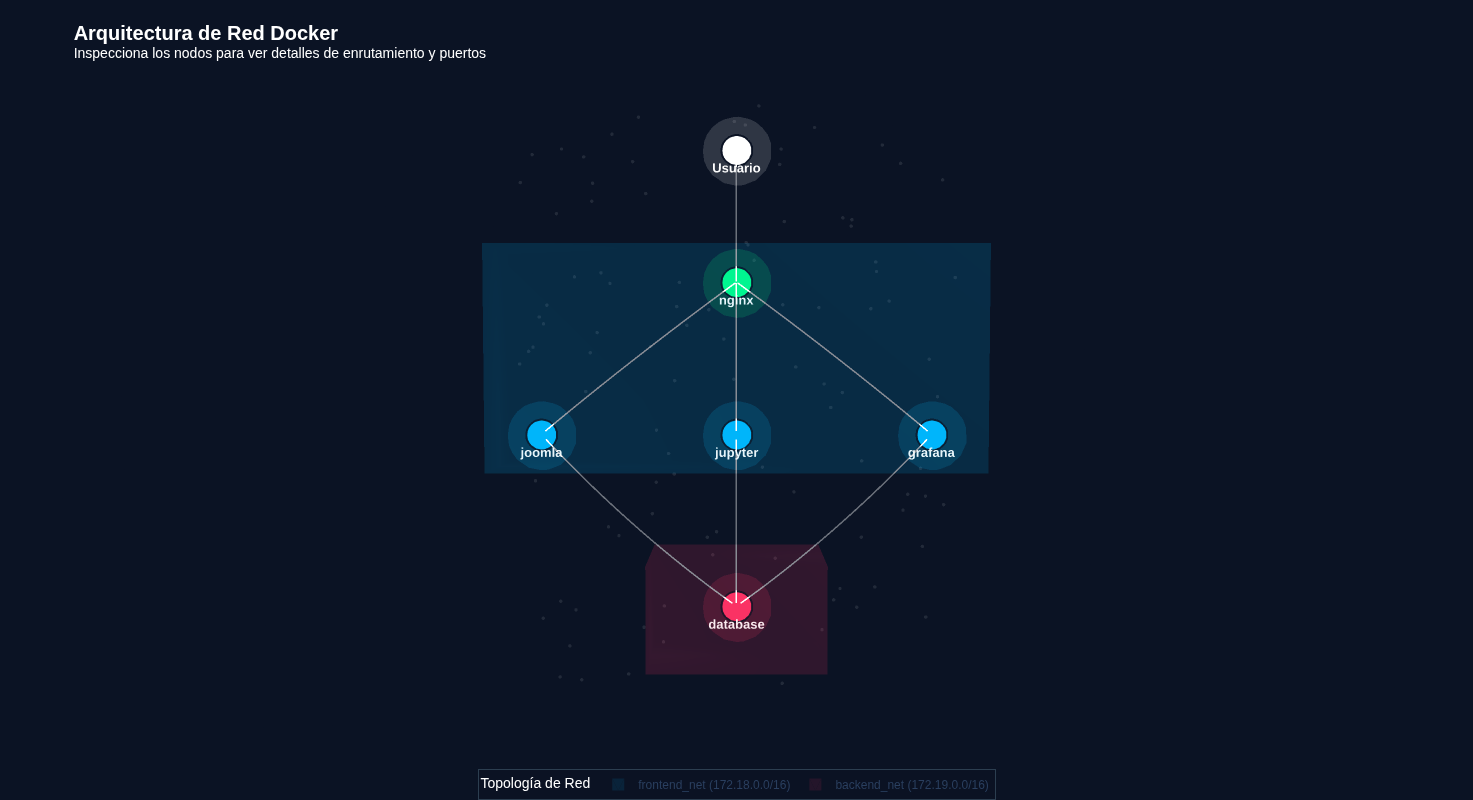

In [6]:
import plotly.graph_objects as go
import numpy as np

# --- 1. Definición de nodos (Distribución Vertical con mayor espaciado) ---
nodos = {
    'Usuario':  {'pos': (0, 0, 8),    'color': '#ffffff', 'info': 'Navegador del cliente<br><i>Acceso externo</i>'},
    'nginx':    {'pos': (0, 0, 5),    'color': '#00ff88', 'info': '<b>nginx:alpine</b><br>TCP 80<br><i>Gateway/Reverse Proxy</i>'},
    'joomla':   {'pos': (-4.5, 0, 1.5),'color': '#00b8ff', 'info': '<b>joomla:latest</b><br>TCP 80 interno<br><i>CMS Frontend</i>'},
    'jupyter':  {'pos': (0, 0, 1.5),  'color': '#00b8ff', 'info': '<b>Jupyter Lab</b><br>TCP 8888 interno<br><i>Data Science Env</i>'},
    'grafana':  {'pos': (4.5, 0, 1.5),'color': '#00b8ff', 'info': '<b>grafana:latest</b><br>TCP 3000 interno<br><i>Dashboarding</i>'},
    'database': {'pos': (0, 0, -2.5), 'color': '#ff3366', 'info': '<b>postgres:16-alpine</b><br>TCP 5432<br><i>Almacenamiento aislado</i>'},
}

aristas = [
    ('Usuario', 'nginx'), ('nginx', 'joomla'), ('nginx', 'jupyter'), ('nginx', 'grafana'),
    ('joomla', 'database'), ('jupyter', 'database'), ('grafana', 'database'),
]

traces = []

# --- 2. Ambiente: Partículas flotantes dispersas ---
np.random.seed(42)
px = np.random.uniform(-5, 5, 100)
py = np.random.uniform(-2, 2, 100)
pz = np.random.uniform(-4, 9, 100)
traces.append(go.Scatter3d(
    x=px, y=py, z=pz, mode='markers',
    marker=dict(size=2, color='#ffffff', opacity=0.1),
    hoverinfo='none', showlegend=False
))

# --- 3. Cajas translúcidas ---
def caja(centro, tam, color, nombre):
    cx, cy, cz = centro
    dx, dy, dz = tam
    x = [cx-dx, cx+dx, cx+dx, cx-dx, cx-dx, cx+dx, cx+dx, cx-dx]
    y = [cy-dy, cy-dy, cy+dy, cy+dy, cy-dy, cy-dy, cy+dy, cy+dy]
    z = [cz-dz, cz-dz, cz-dz, cz-dz, cz+dz, cz+dz, cz+dz, cz+dz]
    return go.Mesh3d(
        x=x, y=y, z=z, color=color, opacity=0.1, alphahull=0,
        name=nombre, showlegend=True, hoverinfo='name',
        lighting=dict(ambient=0.8, diffuse=0.2)
    )

# Cajas ajustadas para cubrir la estructura expandida
traces.append(caja((0, 0, 3.25), (5.5, 1.2, 2.5), '#00b8ff', 'frontend_net (172.18.0.0/16)'))
traces.append(caja((0, 0, -2.5), (2.0, 1.2, 1.2), '#ff3366', 'backend_net (172.19.0.0/16)'))

# --- 4. Curvas de Bézier (Cables arqueados hacia el frente) ---
def generar_curva(p0, p2, num_puntos=20):
    p0 = np.array(p0)
    p2 = np.array(p2)
    punto_medio = (p0 + p2) / 2
    # El arco se proyecta en el eje Y negativo (hacia la cámara) para no cruzarse en el plano vertical
    arco_y = -1.5 
    p1 = np.array([punto_medio[0], punto_medio[1] + arco_y, punto_medio[2]])
    t = np.linspace(0, 1, num_puntos)
    curva = np.outer((1 - t)**2, p0) + np.outer(2 * (1 - t) * t, p1) + np.outer(t**2, p2)
    return curva[:, 0], curva[:, 1], curva[:, 2]

for a, b in aristas:
    cx, cy, cz = generar_curva(nodos[a]['pos'], nodos[b]['pos'])
    traces.append(go.Scatter3d(
        x=cx, y=cy, z=cz, mode='lines',
        line=dict(color='rgba(255, 255, 255, 0.4)', width=3),
        hoverinfo='none', showlegend=False,
    ))

# --- 5. Nodos y Efecto Glow ---
for nombre, datos in nodos.items():
    x, y, z = datos['pos']
    
    traces.append(go.Scatter3d(
        x=[x], y=[y], z=[z], mode='markers',
        marker=dict(size=40, color=datos['color'], opacity=0.15),
        hoverinfo='none', showlegend=False,
    ))
    
    traces.append(go.Scatter3d(
        x=[x], y=[y], z=[z], mode='markers+text',
        marker=dict(size=18, color=datos['color'], line=dict(width=2, color='#0b1324'), opacity=1.0),
        text=[f"<b>{nombre}</b>"], textposition='bottom center',
        textfont=dict(size=13, color='white', family="Arial"),
        hovertemplate=(
            f"<div style='padding:5px; line-height:1.4;'>"
            f"<b style='font-size:16px; color:{datos['color']}'>{nombre.upper()}</b><br>"
            f"<span style='color:#dddddd'>{datos['info']}</span>"
            f"</div><extra></extra>"
        ),
        showlegend=False,
    ))

# --- 6. Configuración General ---
fig_arq = go.Figure(data=traces)
fig_arq.update_layout(
    title=dict(
        text='<b>Arquitectura de Red Docker</b><br><sup>Inspecciona los nodos para ver detalles de enrutamiento y puertos</sup>',
        font=dict(size=20, color='white'),
        x=0.05, y=0.95
    ),
    height=800,
    paper_bgcolor='#0b1324', 
    plot_bgcolor='#0b1324',
    legend=dict(
        title=dict(text='Topología de Red', font=dict(color='white')),
        orientation='h', x=0.5, xanchor='center', y=0.02,
        bgcolor='rgba(11, 19, 36, 0.7)', bordercolor='#2c3e50', borderwidth=1
    ),
    scene=dict(
        # Eliminación definitiva de todos los ejes y suelos
        xaxis=dict(visible=False), 
        yaxis=dict(visible=False), 
        zaxis=dict(visible=False),
        # Ángulo frontal recto
        camera=dict(eye=dict(x=0, y=-2.5, z=0.1)),
        aspectmode='data'
    ),
    margin=dict(l=0, r=0, b=0, t=0),
    hoverlabel=dict(bgcolor="#152136", bordercolor="#2c3e50", font_family="Arial")
)
fig_arq.show()

## 7. Tablas con estilo
La misma tabla de actividad, con gradiente de color para resaltar las tablas más activas de un vistazo (usando `pandas.Styler`).

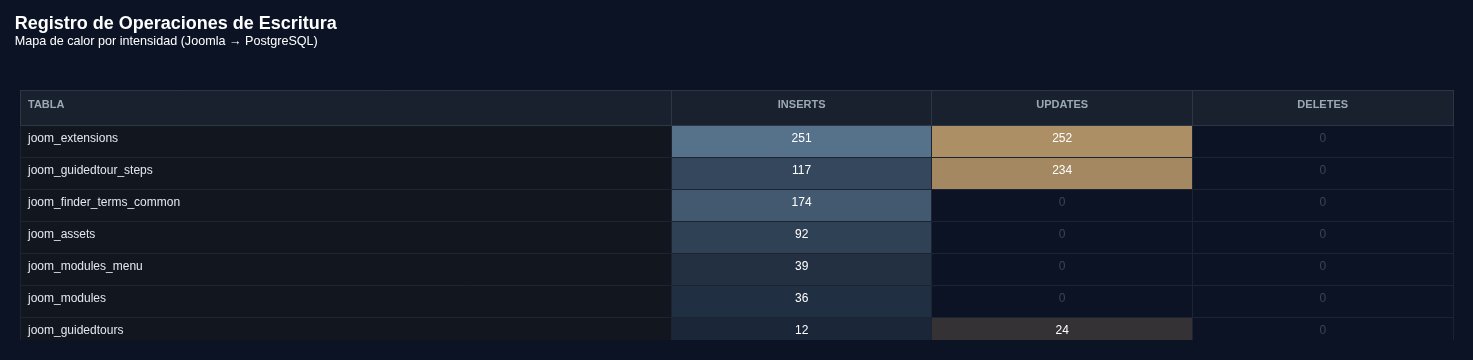

In [7]:
import plotly.graph_objects as go

if not df_actividad.empty:
    # 1. Obtener el valor máximo para escalar la intensidad
    maximo = df_actividad[['inserts', 'updates', 'deletes']].values.max()
    maximo = maximo if maximo > 0 else 1

    # 2. Función para generar colores translúcidos (efecto cristal/Heatmap moderno)
    def color_rgba(v, r, g, b):
        if v == 0:
            return 'rgba(0, 0, 0, 0)' # Fondo transparente si el valor es 0
        # La opacidad (alpha) va de 0.15 (mínima) a 0.85 (máxima) según el valor
        alpha = 0.15 + (v / maximo) * 0.7 
        return f'rgba({r}, {g}, {b}, {alpha:0.2f})'

    # 3. Aplicar la paleta minimalista (Azul Pizarra, Dorado y Rojo Apagado)
    bg_tablas = ['#12161f'] * len(df_actividad)
    bg_inserts = [color_rgba(v, 100, 130, 156) for v in df_actividad['inserts']]
    bg_updates = [color_rgba(v, 201, 166, 113) for v in df_actividad['updates']]
    bg_deletes = [color_rgba(v, 189, 92, 112) for v in df_actividad['deletes']]
    colores_fondo = [bg_tablas, bg_inserts, bg_updates, bg_deletes]

    # 4. Truco visual: Ocultar visualmente los "0" poniéndolos en gris oscuro
    def color_texto(v):
        return '#3b4554' if v == 0 else '#ffffff'
        
    txt_tablas = ['#e2e8f0'] * len(df_actividad)
    txt_inserts = [color_texto(v) for v in df_actividad['inserts']]
    txt_updates = [color_texto(v) for v in df_actividad['updates']]
    txt_deletes = [color_texto(v) for v in df_actividad['deletes']]
    colores_texto = [txt_tablas, txt_inserts, txt_updates, txt_deletes]

    # 5. Construcción de la tabla
    fig_tabla = go.Figure(data=[go.Table(
        columnwidth=[2.5, 1, 1, 1], # La columna de nombres es más ancha
        header=dict(
            values=['<b>TABLA</b>', '<b>INSERTS</b>', '<b>UPDATES</b>', '<b>DELETES</b>'],
            fill_color='#1a212e',
            line_color='#2c3645',
            line_width=1,
            font=dict(color='#9ca8b5', size=11, family='Arial'),
            align=['left', 'center', 'center', 'center'],
            height=35 # Más espacio de respiración
        ),
        cells=dict(
            values=[df_actividad['tabla'], df_actividad['inserts'], df_actividad['updates'], df_actividad['deletes']],
            fill_color=colores_fondo,
            line_color='#1c2331', # Líneas divisorias muy sutiles
            line_width=1,
            font=dict(color=colores_texto, size=12, family='Arial'),
            align=['left', 'center', 'center', 'center'],
            height=32
        )
    )])

    # 6. Configuración global
    fig_tabla.update_layout(
        title=dict(
            text='<b>Registro de Operaciones de Escritura</b><br><sup>Mapa de calor por intensidad (Joomla → PostgreSQL)</sup>',
            font=dict(size=18, color='#ffffff'),
            x=0.01, y=0.92
        ),
        paper_bgcolor='#0b1324', # Fondo que unifica con las gráficas anteriores
        margin=dict(l=20, r=20, t=90, b=20),
    )
    fig_tabla.show()
else:
    print('Aún no hay actividad registrada. Genera tráfico navegando el portal Joomla y vuelve a ejecutar esta celda.')